## Cell 1: Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import sys
from pathlib import Path

# Resolve project root regardless of where the notebook is launched from
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / 'config.yaml').exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid')

with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

# Resolve relative paths in config to absolute so they work from any working directory
config['data']['path'] = str(PROJECT_ROOT / config['data']['path'])
config['embeddings']['cache_path'] = str(PROJECT_ROOT / config['embeddings']['cache_path'])

from pipeline.ingest import load_data
from pipeline.preprocessing import preprocess
from pipeline.embeddings import generate_embeddings
from pipeline.operational_features import encode_metadata
from pipeline.fusion import concatenate_fusion, weighted_fusion
from pipeline.clustering import cluster
from sklearn.metrics import silhouette_score

df = load_data(config['data']['path'], config)
df = preprocess(df, config)
texts = df['text'].tolist()
print('Loading embeddings (cached if available)...')
semantic_vecs = generate_embeddings(texts, config)
operational_vecs = encode_metadata(df, config)
concat_vecs = concatenate_fusion(semantic_vecs, operational_vecs)
print(f'Semantic: {semantic_vecs.shape}, Operational: {operational_vecs.shape}, Fused: {concat_vecs.shape}')

Loading embeddings (cached if available)...
Semantic: (8469, 768), Operational: (8469, 11), Fused: (8469, 779)


## Embedding Model Trade-offs

| Model | Dimensions | Speed (CPU) | SBERT STS Score | Use case |
|---|---|---|---|---|
| all-MiniLM-L6-v2 | 384 | Fast (~30s/8k) | 0.800 | Prototyping, CPU-only |
| all-mpnet-base-v2 | 768 | Medium (~2min/8k) | 0.857 | Production (chosen) |
| paraphrase-multilingual-mpnet | 768 | Medium | 0.830 | Multilingual tickets |

**Chosen:** all-mpnet-base-v2 -- best quality/speed trade-off for batch pipeline.
**Pooling:** Mean pooling of token embeddings -- standard for SentenceTransformers.

## Cell 3: KMeans Elbow Curve

k=2: inertia=4253, silhouette=0.0723
k=3: inertia=4038, silhouette=0.0832
k=4: inertia=3847, silhouette=0.0915
k=5: inertia=3660, silhouette=0.0977
k=6: inertia=3498, silhouette=0.1131
k=7: inertia=3377, silhouette=0.1170
k=8: inertia=3295, silhouette=0.1196
k=9: inertia=3220, silhouette=0.1205
k=10: inertia=3157, silhouette=0.1219
k=11: inertia=3095, silhouette=0.1250
k=12: inertia=3048, silhouette=0.1229
k=13: inertia=2999, silhouette=0.1210
k=14: inertia=2969, silhouette=0.1222
k=15: inertia=2916, silhouette=0.1248


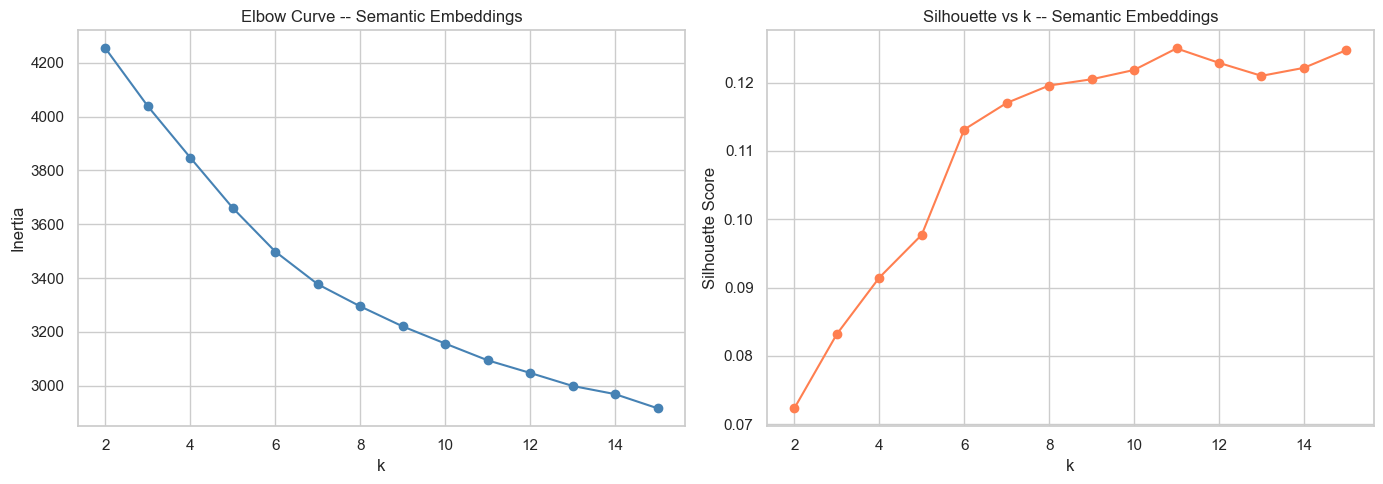


Recommended k: 11 (highest silhouette). Update config.yaml.


In [3]:
from sklearn.cluster import KMeans

k_range = range(2, 16)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42)
    labels = km.fit_predict(semantic_vecs)
    inertias.append(km.inertia_)
    sil = silhouette_score(semantic_vecs[:2000], labels[:2000])
    silhouettes.append(sil)
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve -- Semantic Embeddings')

axes[1].plot(list(k_range), silhouettes, marker='o', color='coral')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette vs k -- Semantic Embeddings')

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'\nRecommended k: {best_k} (highest silhouette). Update config.yaml.')

## Cell 4: HDBSCAN Parameter Sensitivity

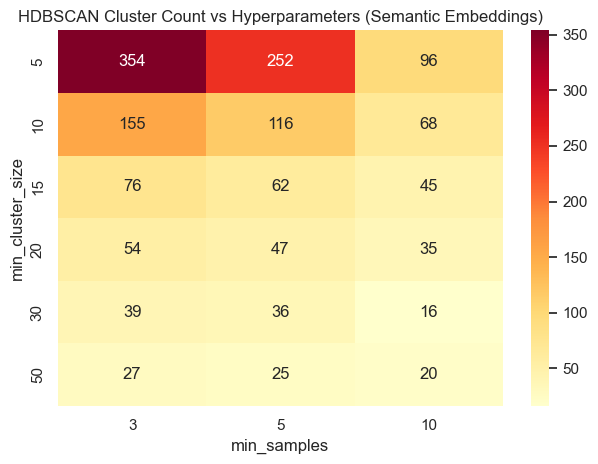

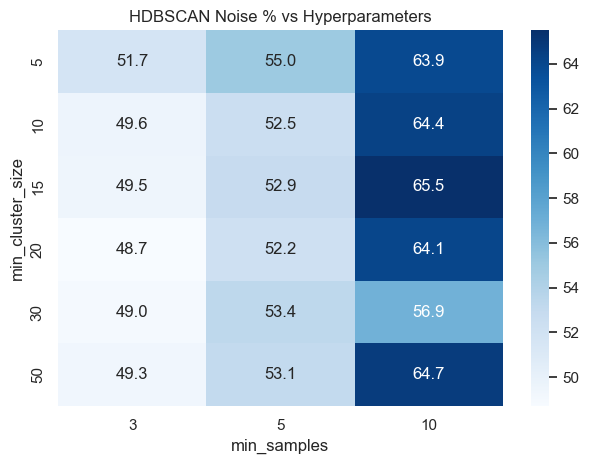


Hyperparameter notes:
- min_cluster_size too small -> fragmented clusters (many small groups)
- min_cluster_size too large -> noise explosion (many -1 labels)
- min_samples higher -> more conservative (more noise, tighter clusters)


In [4]:
import hdbscan

mcs_values = [5, 10, 15, 20, 30, 50]
ms_values = [3, 5, 10]

results = []
for mcs in mcs_values:
    for ms in ms_values:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric='euclidean')
        labels = clusterer.fit_predict(semantic_vecs)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100
        results.append({'min_cluster_size': mcs, 'min_samples': ms,
                        'n_clusters': n_clusters, 'noise_pct': noise_pct})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='min_cluster_size', columns='min_samples', values='n_clusters')
sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd')
plt.title('HDBSCAN Cluster Count vs Hyperparameters (Semantic Embeddings)')
plt.tight_layout()
plt.show()

pivot_noise = results_df.pivot(index='min_cluster_size', columns='min_samples', values='noise_pct')
sns.heatmap(pivot_noise, annot=True, fmt='.1f', cmap='Blues')
plt.title('HDBSCAN Noise % vs Hyperparameters')
plt.tight_layout()
plt.show()

print('\nHyperparameter notes:')
print('- min_cluster_size too small -> fragmented clusters (many small groups)')
print('- min_cluster_size too large -> noise explosion (many -1 labels)')
print('- min_samples higher -> more conservative (more noise, tighter clusters)')

## Cell 5: Fusion Strategy Comparison (Silhouette Heatmap)

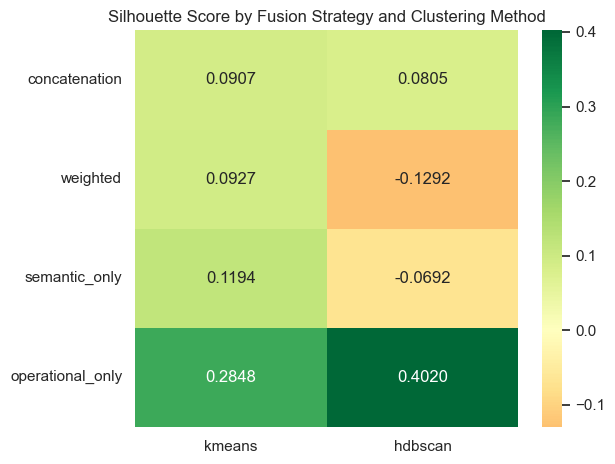

In [5]:
from pipeline.fusion import late_fusion

alpha = config['fusion']['alpha']
fused_vecs = {
    'concatenation': concatenate_fusion(semantic_vecs, operational_vecs),
    'weighted': weighted_fusion(semantic_vecs, operational_vecs, alpha),
    'semantic_only': semantic_vecs,
    'operational_only': operational_vecs,
}

silhouette_matrix = {}
for fname, vecs in fused_vecs.items():
    silhouette_matrix[fname] = {}
    for method in ['kmeans', 'hdbscan']:
        labels = cluster(vecs, method, config)
        mask = labels >= 0
        if mask.sum() > 1 and len(set(labels[mask])) > 1:
            sil = silhouette_score(vecs[:2000], labels[:2000])
        else:
            sil = np.nan
        silhouette_matrix[fname][method] = sil

sil_df = pd.DataFrame(silhouette_matrix).T
sns.heatmap(sil_df, annot=True, fmt='.4f', cmap='RdYlGn', center=0)
plt.title('Silhouette Score by Fusion Strategy and Clustering Method')
plt.tight_layout()
plt.show()

## Cell 6: UMAP Projections

C:\Users\rj194\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


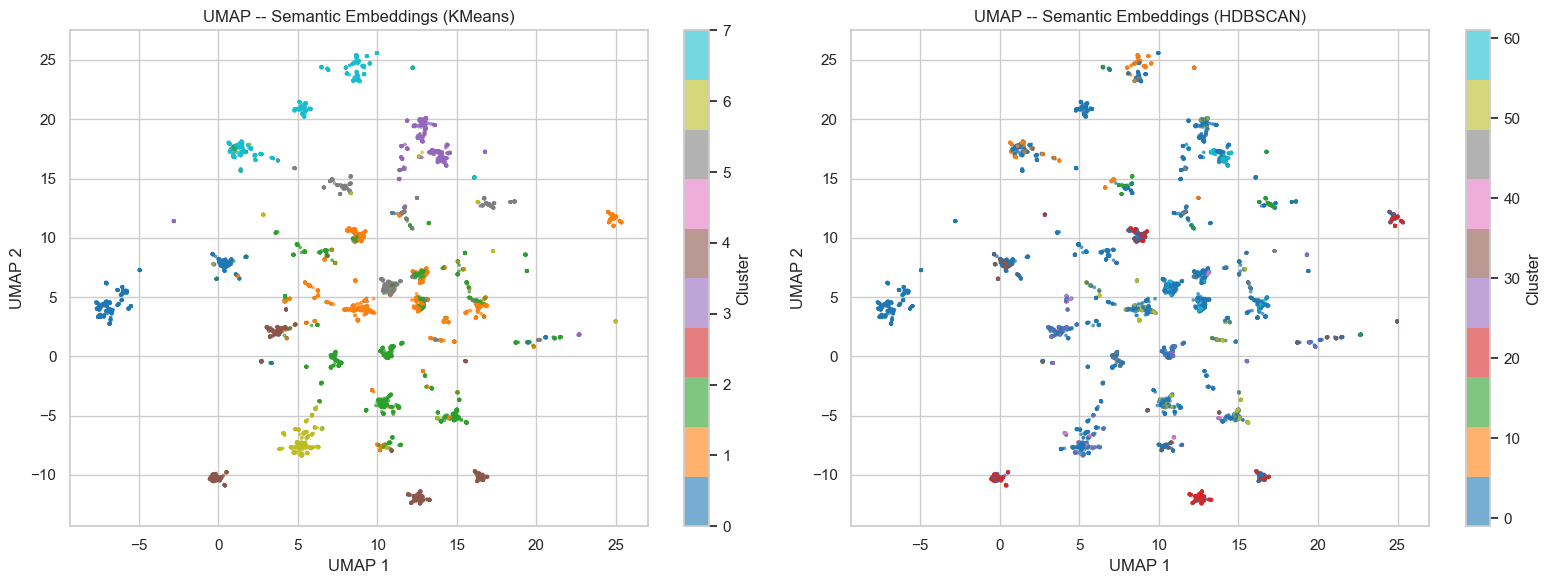

In [6]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(semantic_vecs)

km_labels = cluster(semantic_vecs, 'kmeans', config)
hdb_labels = cluster(semantic_vecs, 'hdbscan', config)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, labels, title in zip(axes, [km_labels, hdb_labels], ['KMeans', 'HDBSCAN']):
    scatter = ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                         c=labels, cmap='tab10', s=3, alpha=0.6)
    ax.set_title(f'UMAP -- Semantic Embeddings ({title})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()